# TASK 3 - Conditional GAN (CGAN)

The vanilla GAN only generates images of random numbers between 0-9 but has no labels associated with the generated images. This means that if you want it to generate MNIST-
looking images of 3s, then it will not understand and generate a random number instead.

Modified the code from Task 1 to create a conditional GAN (CGAN) and then plotted few generated images of numbers like '3' and '8' to see if our GAN knows the classes.


In [25]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import tqdm

# --- Configuration & Device ---
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

mb_size = 128
Z_dim = 100
X_dim = 784
n_classes = 10
lr = 2e-4
beta1 = 0.5
epochs = 64  # CGANs usually show results clearly in less epochs

Using device: cuda:0


In [26]:
# --- Data Preparation ---
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
        transforms.Lambda(lambda x: x.view(-1)),
    ]
)

train_dataset = datasets.MNIST(
    root="./MNIST", train=True, transform=transform, download=True
)
train_loader = DataLoader(
    train_dataset, batch_size=mb_size, shuffle=True, drop_last=True
)

val_dataset = datasets.MNIST(
    root="./MNIST", train=False, transform=transform, download=True
)
val_loader = DataLoader(val_dataset, batch_size=mb_size, shuffle=False, drop_last=True)

**Added the get_one_hot function**

Computers can't read the number 3; they need a vector of 10 bits where the 3rd index is "1". This converts the integer labels from the MNIST dataset into a format the neural network can mathematically concatenate with the noise or image pixels.

In [27]:
# Helper Utilities
def xavier_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)


def get_one_hot(labels, num_classes=10):
    """Converts integer labels to one-hot vectors."""
    return F.one_hot(labels, num_classes).float().to(device)

**Conditional Generator**

Modified the input layer and the forward pass. The input size is increased from Z_dim (100) to 110 to accommodate the 10-digit label vector. By concatenating the label to the noise, we condition the Generator, by telling it to make the digit that matches this label instead of some random digit.

In [28]:
# --- CGAN Architecture (Modified for Two Inputs) ---
class ConditionalGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        # Input is noise (100) + label (10) = 110
        self.net = nn.Sequential(
            nn.Linear(Z_dim + n_classes, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, X_dim),
            nn.Tanh(),
        )
        self.apply(xavier_init)

    def forward(self, z, labels):
        # Concatenate noise and label vector
        combined_input = torch.cat([z, labels], dim=1)
        return self.net(combined_input)


**Conditional Discriminator**

Modified the input layer and added the label to the forward pass. In Task 1, the Discriminator only asked "Is this real?". Now, it asks "Is this a real image AND does it match this label?". This forces the Generator to actually follow instructions. If the Generator makes a perfect '7' but the label says '3', the Discriminator will reject it as fake.

In [29]:
class ConditionalDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # Input is image (784) + label (10) = 794
        self.net = nn.Sequential(
            nn.Linear(X_dim + n_classes, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),  # Output logit
        )
        self.apply(xavier_init)

    def forward(self, x, labels):
        # Concatenate flattened image and label vector
        combined_input = torch.cat([x, labels], dim=1)
        return self.net(combined_input)

**Modified Training Loop**

Updated the data loader loop and the loss calculation. We now extract y_real (the actual label) from the dataset. During training, both the real images and the generated images are paired with their correct labels. This ensures the entire adversarial game is played with the context of the digit class.

In [30]:
# --- Training Loop ---
G = ConditionalGenerator().to(device)
D = ConditionalDiscriminator().to(device)

G_solver = optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
D_solver = optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))
loss_fn = nn.BCEWithLogitsLoss()

D_loss_history = []
G_loss_history = []
D_val_loss_history = []
G_val_loss_history = []

print("Starting CGAN Training...")
for epoch in range(epochs):
    G.train()
    D.train()
    pbar = tqdm.tqdm(train_loader, desc=f"Epoch {epoch}")
    epoch_D_loss = 0.0
    epoch_G_loss = 0.0

    for X_real, y_real in pbar:
        bsz = X_real.size(0)
        X_real = X_real.to(device)
        y_onehot = get_one_hot(y_real)

        # Labels for Binary Cross Entropy
        real_target = torch.full((bsz, 1), 0.9, device=device)  # Label smoothing
        fake_target = torch.zeros((bsz, 1), device=device)

        # Train Discriminator
        # D(x, y) should be 1; D(G(z, y), y) should be 0
        z = torch.randn(bsz, Z_dim, device=device)
        G_sample = G(z, y_onehot)

        D_real = D(X_real, y_onehot)
        D_fake = D(G_sample.detach(), y_onehot)

        D_loss = loss_fn(D_real, real_target) + loss_fn(D_fake, fake_target)

        D_solver.zero_grad()
        D_loss.backward()
        D_solver.step()

        # Train Generator
        # G(z, y) should fool D into thinking it's 1
        z = torch.randn(bsz, Z_dim, device=device)
        G_sample = G(z, y_onehot)
        D_fake = D(G_sample, y_onehot)
        G_loss = loss_fn(D_fake, torch.ones((bsz, 1), device=device))

        G_solver.zero_grad()
        G_loss.backward()
        G_solver.step()

        epoch_D_loss += D_loss.item()
        epoch_G_loss += G_loss.item()
        pbar.set_postfix(D_loss=f"{D_loss.item():.3f}", G_loss=f"{G_loss.item():.3f}")

    avg_D_loss = epoch_D_loss / len(train_loader)
    avg_G_loss = epoch_G_loss / len(train_loader)
    D_loss_history.append(avg_D_loss)
    G_loss_history.append(avg_G_loss)

    # Validation
    G.eval()
    D.eval()
    val_D_loss = 0.0
    val_G_loss = 0.0
    with torch.no_grad():
        for X_real, y_real in val_loader:
            bsz = X_real.size(0)
            X_real = X_real.to(device)
            y_onehot = get_one_hot(y_real)
            real_target = torch.full((bsz, 1), 0.9, device=device)
            fake_target = torch.zeros((bsz, 1), device=device)
            z = torch.randn(bsz, Z_dim, device=device)
            G_sample = G(z, y_onehot)
            D_real = D(X_real, y_onehot)
            D_fake = D(G_sample, y_onehot)
            D_loss = loss_fn(D_real, real_target) + loss_fn(D_fake, fake_target)
            G_loss = loss_fn(D_fake, torch.ones((bsz, 1), device=device))
            val_D_loss += D_loss.item()
            val_G_loss += G_loss.item()
    avg_val_D = val_D_loss / len(val_loader)
    avg_val_G = val_G_loss / len(val_loader)
    D_val_loss_history.append(avg_val_D)
    G_val_loss_history.append(avg_val_G)
    print(
        f"Epoch {epoch + 1}/{epochs} - D_loss: {avg_D_loss:.4f} - G_loss: {avg_G_loss:.4f} - val_D_loss: {avg_val_D:.4f} - val_G_loss: {avg_val_G:.4f}"
    )


Starting CGAN Training...


Epoch 0: 100%|██████████| 468/468 [00:09<00:00, 50.38it/s, D_loss=1.331, G_loss=3.134]


Epoch 1/64 - D_loss: 1.0249 - G_loss: 1.5600 - val_D_loss: 1.0007 - val_G_loss: 2.5104


Epoch 1: 100%|██████████| 468/468 [00:08<00:00, 52.65it/s, D_loss=0.897, G_loss=2.249]


Epoch 2/64 - D_loss: 0.9261 - G_loss: 2.0595 - val_D_loss: 0.7093 - val_G_loss: 1.7236


...

Epoch 62/64 - D_loss: 1.3254 - G_loss: 0.9124 - val_D_loss: 1.3528 - val_G_loss: 0.9556


Epoch 62: 100%|██████████| 468/468 [00:09<00:00, 49.68it/s, D_loss=1.306, G_loss=0.914]


Epoch 63/64 - D_loss: 1.3262 - G_loss: 0.9095 - val_D_loss: 1.3587 - val_G_loss: 0.9891


Epoch 63: 100%|██████████| 468/468 [00:09<00:00, 50.09it/s, D_loss=1.312, G_loss=0.977]


Epoch 64/64 - D_loss: 1.3275 - G_loss: 0.9063 - val_D_loss: 1.3424 - val_G_loss: 1.0179


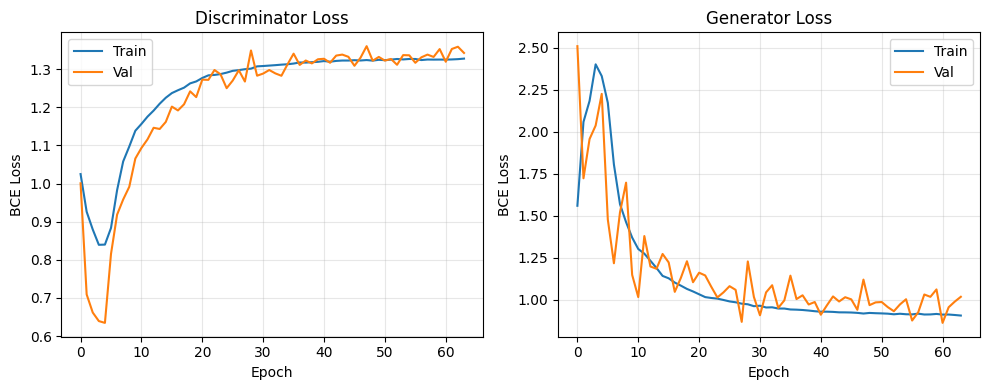

In [31]:
# --- Plot Training and Validation Losses ---
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(D_loss_history, label="Train")
plt.plot(D_val_loss_history, label="Val")
plt.title("Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(G_loss_history, label="Train")
plt.plot(G_val_loss_history, label="Val")
plt.title("Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Added plot_chosen_digit**

This proves the CGAN works. By passing a hardcoded label (like 3) and random noise, we can verify that the model has successfully learned to map the label input to the correct visual output.

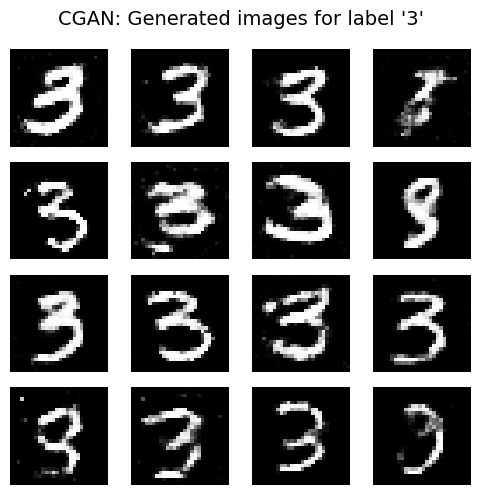

In [32]:
# --- Plotting Results ---
def plot_chosen_digit(generator, digit, n=16):
    """Generates and plots 'n' images of the specified digit."""
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n, Z_dim, device=device)
        labels = torch.full((n,), digit, dtype=torch.long, device=device)
        y_onehot = get_one_hot(labels)
        samples = generator(z, y_onehot).cpu().numpy()

    samples = (samples + 1) / 2  # Denormalize [-1,1] to [0,1]

    plt.figure(figsize=(5, 5))
    plt.suptitle(f"CGAN: Generated images for label '{digit}'", fontsize=14)
    for i in range(n):
        plt.subplot(4, 4, i + 1)
        plt.imshow(samples[i].reshape(28, 28), cmap="Greys_r")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


# Final Verification: Try generating any number 0-9
plot_chosen_digit(G, digit=3)

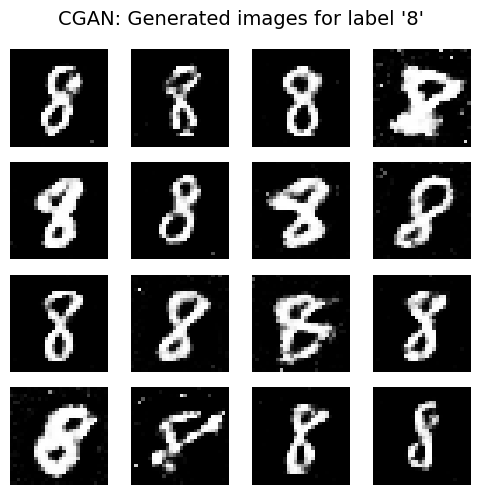

In [33]:
plot_chosen_digit(G, digit=8)